In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
from functools import partial
sys.path.append("..")
from src.models import NeuralPosteriorEstimator, MarginalDensityFlow
from src.data.sir_model import SIRModel, HetSIRModel
from src.criticism import c2st, z_test

mps_device = torch.device("mps")

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a

In [3]:
noise = {"distr": "normal", "scale":2} # doubling the noise to account for a doubled sample size

# Experiment Outline

Motivation: can we identify the heterogeneity (in terms of susceptibility) of an SIR-type outbreak?

* Maybe we start simple. Instead of skipping to 5 susceptibility bins, start with 2?
* First trial: the data is *really* homogeneous. Can we successfully reduce to a simpler model?
* Second trial: the data is *really* heterogeneous. Can we flag that a homogeneous model is misspecified?

# Homogeneous SIR Model

In [3]:
model1 = SIRModel(1.5, .5, 200, 10, [1, 1], n_sample=10, observed_seed=28, p_init=0.025, partial_obs=True)

Simulating samples...


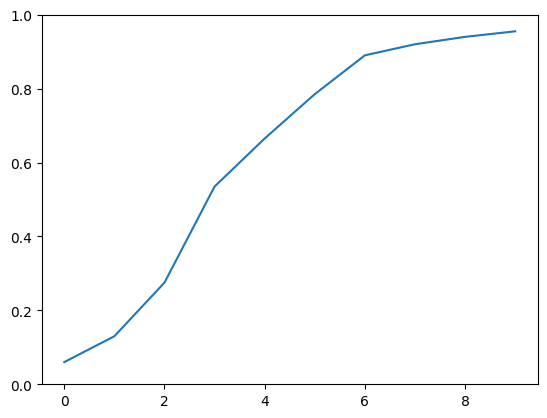

In [4]:
X1 = model1.get_observed_data()
plt.plot(X1[0][0])
plt.ylim(0, 1)
plt.show()

# Heterogeneous SIR Model

In [5]:
betas = [1, 1.5, 2, 2.5, 3] # [0.67, 1, 1.5, 2.25, 3]
prior_scale = [1,1,1,1,1,1]

In [6]:
model2 = HetSIRModel(betas, 1, 200, 10, prior_scale, n_sample=10, observed_seed=7)

Simulating samples...


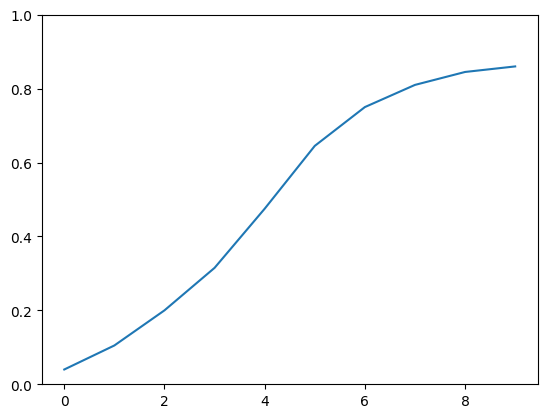

In [7]:
X2 = model2.get_observed_data()
plt.plot(X2.reshape(5, 10).mean(0))
plt.ylim(0, 1)
plt.show()

# Experiment 1: ID-ing Homogeneous Susceptibility

* Same procedure as before: generate 20 datasets with different seeds where the susceptibility is homogeneous
* three (3) different procedures for model selection

1. NPE Posterior Predictive Checks (fit two models; run 100 simulations)
2. MDE Hypothesis Testing
3. MDE Bayes Factors

Expected challenge: scaling up normalizing flows to higher dimensional data
- embedding network?
- training MDE on NPE encodings?

In [8]:
K = 5
betas = np.ones(K) * 1.5
prior_scale = np.ones(K+1)

In [9]:
true_dataset = HetSIRModel(betas, gamma=.5, prior_scale=prior_scale, N=200, T=10, observed_seed=9, n_sample=N,
                  mode="estimation", load_data=False)

Simulating samples...


In [10]:
# generate 20 "observed" datasets from the homogeneous SIR model
# this is going to be less trivial than I previously thought?

I = 20
observed_data = torch.empty((I, 50))
for i in range(I):
    # not a very elegant solution
    prior = torch.distributions.Gamma(1, 1)
    beta = prior.sample((1,))[0]
    gamma = prior.sample((1,))[0]
    theta = torch.empty(K+1)
    theta[-1] = gamma
    theta[:-1] = beta
    observed_data[i] = true_dataset.simulate(theta)

## Approach One: Posterior Predictive Checks

In [11]:
homo_dataset = SIRModel(0, 0, 200, 10, prior_scale=[1, 1], n_sample=N, mode="estimation", partial_obs=True)
train_data, val_data = random_split(homo_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [12]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = NeuralPosteriorEstimator(2, 10, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 21.0 K | train
-------------------------------------------
21.0 K    Trainable params
0         Non-trainable params
21.0 K    Total params
0.084     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                          | 0/? [00:00<?, ?it/s]

Training: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                               | 0/? [00:00<?, ?it/s]

In [17]:
def homogenize(data, K, T):
    return data.reshape(K, T).mean(0)

In [18]:
homogenize(observed_data[i], 5, 10)

tensor([0.0350, 0.0400, 0.0450, 0.0500, 0.0550, 0.0650, 0.0650, 0.0650, 0.0650,
        0.0650])

In [24]:
J = 100
ppe = np.empty(I,)
for i in range(I):
    x_o = homogenize(observed_data[i], 5, 10)
    posterior = model.sample(J, x_o)
    posterior_predictive = np.empty((J, 10))
    for j in range(J):
        z = torch.exp(posterior[j])
        x = homo_dataset.simulate(z)
        posterior_predictive[j] = x
    error = ((posterior_predictive - x_o.numpy())**2).sum(1).mean(0)
    ppe[i] = error
ppe.mean()

np.float64(0.08248242121234624)

In [21]:
het_dataset = HetSIRModel(np.ones(5), 1, 200, 10, prior_scale=np.ones(6), n_sample=N, mode="estimation")
train_data, val_data = random_split(het_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [22]:
# try some multiruns to make sure you're training these effectively
# it appears they don't make a ton of difference
optim = partial(torch.optim.AdamW, lr=0.0005)
model = NeuralPosteriorEstimator(6, 50, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 34.4 K | train
-------------------------------------------
34.4 K    Trainable params
0         Non-trainable params
34.4 K    Total params
0.137     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                            | 0/? [00:00<?, ?it/s]

Training: |                                                   | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

...

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

In [ ]:
model.

In [40]:
J = 100
ppe = np.empty(I,)
for i in range(I):
    x_o = observed_data[i]
    posterior = model.sample(J, x_o)
    posterior_predictive = np.empty((J, 50))
    for j in range(J):
        z = torch.exp(posterior[j])
        x = het_dataset.simulate(z)
        posterior_predictive[j] = x
    error = ((posterior_predictive - x_o.numpy())**2).sum(1).mean(0)
    ppe[i] = error
ppe.mean()

np.float64(0.7659428121203701)

## Approach 2: Marginal Density Estimation

Anticipating the big challenge will be learning (relatively) high dimensional data's distribution
What's the alternative? Training NPE with low-dimensional embeddings.?

### Homogeneous Model Estimate

In [51]:
homo_dataset = SIRModel(0, 0, 200, 10, prior_scale=[1, 1], n_sample=N, mode="criticism", partial_obs=True,
                       noise=noise)
train_data, val_data = random_split(homo_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [52]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(10, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 30.8 K | train
--------------------------------------
30.8 K    Trainable params
0         Non-trainable params
30.8 K    Total params
0.123     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                            | 0/? [00:00<?, ?it/s]

Training: |                                                   | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

...

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

In [53]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                 | 0/? [00:00<?, ?it/s]

tensor(0.5513, dtype=torch.float64)

### Heterogeneous Model Estimate

In [4]:
hetero_dataset = HetSIRModel(np.zeros(5), 0, 200, 10, prior_scale=np.ones(6), n_sample=N, mode="criticism",
                       noise=noise)
train_data, val_data = random_split(hetero_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [19]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(50, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 69.6 K | train
--------------------------------------
69.6 K    Trainable params
0         Non-trainable params
69.6 K    Total params
0.278     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                            | 0/? [00:00<?, ?it/s]

Training: |                                                   | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

...

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                 | 0/? [00:00<?, ?it/s]

In [ ]:
# plt.plot(x_val[:100, 0, :].T, alpha=0.1, color="tab:blue")
# plt.ylim(-0.1, 1.1)
# plt.show()

In [20]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

# ain't know way, son

Predicting: |                                                 | 0/? [00:00<?, ?it/s]

tensor(0.9375, dtype=torch.float64)